# TP Module 3 — VAE : Variational Autoencoder (DermaMNIST & séries temporelles)

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

1. Comprendre pourquoi l'AE déterministe (TP 07) **ne sait pas générer**, et formuler le **modèle génératif à variable latente** : $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$, $\mathbf{x}\sim p_\theta(\mathbf{x}|\mathbf{z})$
2. Dériver l'**ELBO** (*Evidence Lower BOund*) et interpréter ses deux termes : **reconstruction** + **régularisation KL**
3. Implémenter le **reparametrization trick** ($\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma}\odot\boldsymbol{\epsilon}$) et la **KL en forme close**, vérifiés contre `torch.distributions`
4. Entraîner un **ConvVAE** sur DermaMNIST avec **KL annealing**, puis **générer** des images en échantillonnant le prior
5. Explorer le **$\beta$-VAE** : compromis reconstruction / désenchevêtrement, et **dimensions latentes actives**
6. Conditionner la génération par classe avec un **Conditional VAE** (CVAE) — augmentation de données pour les classes rares
7. Interpoler dans l'espace latent (**lerp** vs **slerp**) et générer des **séries temporelles synthétiques** avec un VAE 1D (`nn.Conv1d`)

## Pré-requis

- Modules 1 et 2, et **TP 07** (autoencoders — l'architecture convolutive est réutilisée telle quelle)
- `torch`, `torchvision`, `medmnist`, `matplotlib`, `numpy`, `scikit-learn` ; **optionnel** : `umap-learn`

## Dataset

Toujours le **fil rouge médical** sur **DermaMNIST** (collection [MedMNIST](https://medmnist.com/), dérivé de HAM10000) — images dermatoscopiques **RGB** de lésions cutanées, **7 classes**, fortement **déséquilibré** (*melanocytic nevi* — `nv` — domine). L'entraînement du VAE reste **non supervisé** : les labels ne servent qu'au **conditionnement du CVAE** (Partie IX) et à *colorer* la projection latente. Téléchargement automatique via `medmnist` dans `./data/`. La Partie XI utilise en complément des **signaux capteurs simulés** (générés à la volée, rien à télécharger).

## Partie I — Théorie du Variational Autoencoder

### I.1 De l'AE déterministe au modèle génératif

Le TP 07 s'est conclu sur une limite (exercice 6) : si l'on échantillonne $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ et qu'on le passe au décodeur d'un AE **déterministe**, on obtient des images **non réalistes**. Le latent de l'AE n'a **aucune structure probabiliste** : les codes des images d'entraînement forment des îlots arbitraires, séparés par des zones « vides » que le décodeur n'a jamais vues, et il n'existe **aucun prior** indiquant où échantillonner.

Le **VAE** (Kingma & Welling, 2014) répare cela en postulant un **processus génératif** :

$$
\mathbf{z}\sim p(\mathbf{z})=\mathcal{N}(\mathbf{0},\mathbf{I}),
\qquad
\mathbf{x}\sim p_\theta(\mathbf{x}\,|\,\mathbf{z}).
$$

Apprendre $\theta$ par maximum de vraisemblance exigerait la **vraisemblance marginale**

$$
p_\theta(\mathbf{x}) = \int p_\theta(\mathbf{x}\,|\,\mathbf{z})\,p(\mathbf{z})\,d\mathbf{z},
$$

**intractable** (intégrale sur tout l'espace latent). Le postérieur $p_\theta(\mathbf{z}\,|\,\mathbf{x})$ l'est tout autant — il faut une approximation.

### I.2 Inférence variationnelle & ELBO

**Solution** : on introduit un **encodeur probabiliste** $q_\phi(\mathbf{z}\,|\,\mathbf{x})$ qui approxime le vrai postérieur. On le choisit **gaussien diagonal** :

$$
q_\phi(\mathbf{z}\,|\,\mathbf{x}) = \mathcal{N}\bigl(\boldsymbol{\mu}_\phi(\mathbf{x}),\ \mathrm{diag}(\boldsymbol{\sigma}^2_\phi(\mathbf{x}))\bigr),
$$

ce qui se traduit par **deux têtes** en sortie d'encodeur : $\boldsymbol{\mu}\in\mathbb{R}^d$ et $\log\boldsymbol{\sigma}^2\in\mathbb{R}^d$ (prédire la **log-variance** garantit $\sigma^2>0$ et stabilise l'optimisation). Chaque image devient un **nuage** latent, pas un point.

**Décomposition de la log-vraisemblance.** Pour toute distribution $q_\phi$ :

$$
\log p_\theta(\mathbf{x})
= \underbrace{\mathbb{E}_{q_\phi}\!\Bigl[\log\tfrac{p_\theta(\mathbf{x},\mathbf{z})}{q_\phi(\mathbf{z}|\mathbf{x})}\Bigr]}_{\mathcal{L}_{\text{ELBO}}(\theta,\phi;\,\mathbf{x})}
\;+\;
\underbrace{\mathrm{KL}\bigl(q_\phi(\mathbf{z}|\mathbf{x})\,\|\,p_\theta(\mathbf{z}|\mathbf{x})\bigr)}_{\ge\, 0}
\quad\Longrightarrow\quad
\log p_\theta(\mathbf{x}) \;\ge\; \mathcal{L}_{\text{ELBO}}.
$$

La log-vraisemblance étant intractable, on maximise la **borne inférieure calculable** — d'autant plus serrée que $q_\phi$ approche le vrai postérieur. En développant $p_\theta(\mathbf{x},\mathbf{z}) = p_\theta(\mathbf{x}|\mathbf{z})\,p(\mathbf{z})$, l'ELBO prend sa **forme exploitable** :

$$
\mathcal{L}_{\text{ELBO}} =
\underbrace{\mathbb{E}_{q_\phi(\mathbf{z}|\mathbf{x})}\bigl[\log p_\theta(\mathbf{x}|\mathbf{z})\bigr]}_{\text{reconstruction}}
\;-\;
\underbrace{\mathrm{KL}\bigl(q_\phi(\mathbf{z}|\mathbf{x})\,\|\,p(\mathbf{z})\bigr)}_{\text{régularisation latente}} .
$$

- Le 1ᵉʳ terme est la **fidélité** — c'est l'AE classique (décodeur gaussien $\Rightarrow$ MSE, Bernoulli $\Rightarrow$ BCE).
- Le 2ᵉ est le « loyer » d'un **latent rangé** autour du prior $\mathcal{N}(\mathbf{0},\mathbf{I})$, sans trous — **c'est lui qui rend la génération possible**.

### I.3 Reparametrization trick & KL analytique

**Le problème du gradient.** Échantillonner $\mathbf{z}\sim q_\phi(\mathbf{z}|\mathbf{x})$ est une opération **stochastique non différentiable** en $\phi$ : on ne peut pas rétropropager à travers un tirage aléatoire.

**Reparametrization trick** — on sort l'aléa du chemin de gradient :

$$
\mathbf{z} = \boldsymbol{\mu}_\phi(\mathbf{x}) + \boldsymbol{\sigma}_\phi(\mathbf{x})\odot\boldsymbol{\epsilon},
\qquad
\boldsymbol{\epsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

$\boldsymbol{\mu}$ et $\boldsymbol{\sigma}$ sont des fonctions **déterministes** de $\mathbf{x}$ ; l'aléa $\boldsymbol{\epsilon}$ devient une **entrée externe** $\Rightarrow$ le gradient circule. En PyTorch : `z = mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)`.

**KL en forme close.** Entre $q=\mathcal{N}(\boldsymbol{\mu},\mathrm{diag}(\boldsymbol{\sigma}^2))$ et $p=\mathcal{N}(\mathbf{0},\mathbf{I})$, la KL se calcule **analytiquement** (pas d'échantillonnage) :

$$
\mathrm{KL}(q\,\|\,p) = -\frac{1}{2}\sum_{j=1}^{d}\bigl(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\bigr).
$$

**Exemple numérique** ($d=2$, celui du cours) : $\boldsymbol{\mu}=(0.5,\,-0.3)$, $\boldsymbol{\sigma}=(0.8,\,1.2)$ :

$$
\begin{aligned}
j=1 &: \quad 1 + \log 0.64 - 0.25 - 0.64 = -0.336\\
j=2 &: \quad 1 + \log 1.44 - 0.09 - 1.44 = -0.165\\
\mathrm{KL} &= -\tfrac{1}{2}(-0.501) = 0.250\ \text{nats}.
\end{aligned}
$$

On vérifiera ce calcul **from scratch** puis avec `torch.distributions.kl_divergence` (Partie III).

### I.4 Loss pratique : $-\mathcal{L}_{\text{ELBO}}$, $\beta$-VAE & KL annealing

En pratique on **minimise** l'opposé de l'ELBO, avec un poids $\beta$ sur la KL :

$$
\mathcal{L}_{\text{VAE}} =
\underbrace{\|\mathbf{x}-\hat{\mathbf{x}}\|_2^2}_{\text{reconstruction (MSE)}}
\;+\; \beta\cdot
\underbrace{\mathrm{KL}\bigl(q_\phi\,\|\,p\bigr)}_{\text{forme close}} .
$$

- $\beta = 1$ : VAE standard (l'ELBO exact, à la variance du décodeur près).
- $\beta > 1$ : **$\beta$-VAE** (Higgins et al., 2017) — pression accrue vers le prior, qui force un latent **désenchevêtré** (*disentangled*) : chaque dimension tend à capturer un **facteur de variation indépendant**, au prix d'une reconstruction plus floue.
- $\beta \ll 1$ : la KL ne contraint presque plus rien — on retombe vers l'AE déterministe (bonnes reconstructions, génération dégradée).

⚠️ **Posterior collapse** : si la KL domine trop tôt, l'optimum trivial est $q_\phi \to p$ — le latent est **ignoré** ($\mathrm{KL}\approx 0$, toutes les sorties se ressemblent). Remède classique : le **KL annealing** — démarrer avec $\beta_{\text{eff}}\approx 0$ et l'augmenter linéairement pendant les premières epochs :

$$
\beta_{\text{eff}}(t) = \beta\cdot\min\!\Bigl(1,\ \frac{t}{t_{\text{warmup}}}\Bigr).
$$

### I.5 Génération, interpolation latente & Conditional VAE

**Génération.** Après entraînement, on *jette l'encodeur* : $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ puis $\hat{\mathbf{x}} = D_\theta(\mathbf{z})$. Le terme KL garantit que le prior couvre la région utile du latent — exactement ce qui manquait à l'AE. **Le décodeur seul est le générateur.**

**Interpolation latente.** Entre deux codes $\mathbf{z}_a, \mathbf{z}_b$, on parcourt un chemin et on décode chaque point :

$$
\text{lerp} : \mathbf{z}_t = (1-t)\,\mathbf{z}_a + t\,\mathbf{z}_b,
\qquad
\text{slerp} : \mathbf{z}_t = \frac{\sin((1-t)\Omega)}{\sin\Omega}\,\mathbf{z}_a + \frac{\sin(t\Omega)}{\sin\Omega}\,\mathbf{z}_b,
$$

avec $\Omega = \angle(\mathbf{z}_a, \mathbf{z}_b)$. Sous le prior gaussien, $\|\mathbf{z}\|\approx\sqrt{d}$ (concentration de la mesure) : le **slerp** (interpolation *sphérique*) respecte cette norme typique, alors que le milieu du lerp passe par une zone de norme trop faible — d'où un morphing souvent plus réaliste en slerp.

**Conditional VAE (CVAE).** Pour **contrôler la classe** générée, on concatène un label $\mathbf{y}$ (one-hot ou `nn.Embedding`) à l'entrée de l'encodeur **et** au latent du décodeur :

$$
q_\phi(\mathbf{z}\,|\,\mathbf{x},\mathbf{y}),
\qquad
p_\theta(\mathbf{x}\,|\,\mathbf{z},\mathbf{y}).
$$

Application directe sur DermaMNIST : **augmentation de données** pour les classes rares (`df`, `vasc`…). Même principe en 1D pour générer des **séries temporelles capteurs synthétiques** (Partie XI).

⚠️ **Limite connue** : les reconstructions/générations VAE sont un peu **floues** (moyenne sous la gaussienne du décodeur) — c'est la motivation directe des **modèles de diffusion** (TP 09).

## Partie II — Préparation des données

Comme au TP 07 : **pas de normalisation ImageNet** — pixels dans $[0,1]$, cohérents avec une sortie sigmoïde et une loss MSE. Les labels sont conservés pour le **CVAE** et la coloration des projections latentes.

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.transforms import v2 as T
from medmnist import DermaMNIST, INFO

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")

ROOT     = Path("./data")
CKPT_DIR = Path("./checkpoints")
ROOT.mkdir(exist_ok=True); CKPT_DIR.mkdir(exist_ok=True)

IMG_SIZE   = 64               # 64×64 — résolution native demandée à MedMNIST (fallback : upscaling depuis 28×28)
BATCH      = 128
LATENT_DIM = 128              # dimension du latent z du ConvVAE

info          = INFO["dermamnist"]
NUM_CLASSES   = len(info["label"])                                  # 7
CLASSES       = [info["label"][str(i)] for i in range(NUM_CLASSES)] # noms longs
CLASSES_SHORT = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print(f"Classes ({NUM_CLASSES}) :")
for i, name in enumerate(CLASSES):
    print(f"  {i} — {CLASSES_SHORT[i]:<6} {name}")

PyTorch  : 2.10.0
Device   : cpu
Classes (7) :
  0 — akiec  actinic keratoses and intraepithelial carcinoma
  1 — bcc    basal cell carcinoma
  2 — bkl    benign keratosis-like lesions
  3 — df     dermatofibroma
  4 — mel    melanoma
  5 — nv     melanocytic nevi
  6 — vasc   vascular lesions


In [2]:
def make_derma(split, transform=None, target_transform=None):
    '''Charge un split DermaMNIST en demandant size=IMG_SIZE (RGB natif),
    avec repli sur 28×28 si la version de medmnist ne connaît pas `size`.'''
    kwargs = dict(split=split, root=ROOT, download=True,
                  transform=transform, target_transform=target_transform)
    try:
        return DermaMNIST(size=IMG_SIZE, **kwargs)
    except TypeError:
        return DermaMNIST(**kwargs)            # medmnist < 3.0 : images 28×28

# L'étiquette MedMNIST est un tableau (1,) -> entier scalaire (CVAE + coloration latente)
# /!\ Fonction NOMMÉE (pas un lambda) : un lambda n'est pas picklable, ce qui fait
# planter DataLoader(num_workers > 0) sous macOS/Windows (méthode « spawn »).
def squeeze_target(t):
    return int(np.asarray(t).reshape(-1)[0])

# Transformation : simple passage en tenseur float32 dans [0, 1] (pas de normalisation ImageNet)
to_tensor = T.Compose([
    T.Resize(IMG_SIZE, antialias=True),
    T.CenterCrop(IMG_SIZE),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),     # uint8 [0,255] -> float [0,1]
])

train_set = make_derma("train", transform=to_tensor, target_transform=squeeze_target)
val_set   = make_derma("val",   transform=to_tensor, target_transform=squeeze_target)
test_set  = make_derma("test",  transform=to_tensor, target_transform=squeeze_target)

print(f"Train : {len(train_set)}  |  Val : {len(val_set)}  |  Test : {len(test_set)}")
x0, y0 = train_set[0]
print(f"Tenseur image : {tuple(x0.shape)}  dtype={x0.dtype}  min={x0.min():.2f}  max={x0.max():.2f}")
print(f"Label exemple : {y0} ({CLASSES_SHORT[y0]})")

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0, drop_last=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0)

Train : 7007  |  Val : 1003  |  Test : 2005
Tenseur image : (3, 64, 64)  dtype=torch.float32  min=0.31  max=0.84
Label exemple : 0 (akiec)


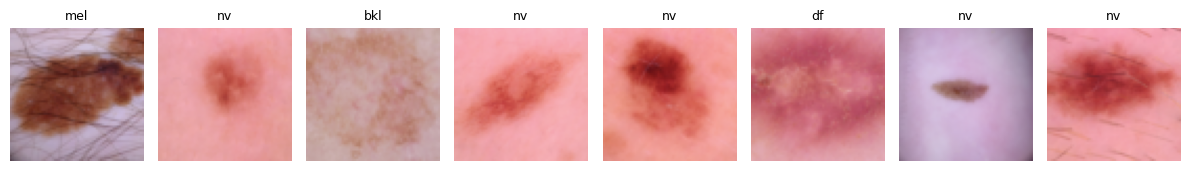

Batch : (128, 3, 64, 64)


In [3]:
# Aperçu : 8 images du train
def show_grid(imgs, titles=None, nrow=8, figsize=None, cmap=None):
    '''Affiche une grille d'images (tenseurs CHW dans [0,1]).'''
    n = len(imgs)
    ncol = nrow
    nrows = (n + ncol - 1) // ncol
    figsize = figsize or (1.5 * ncol, 1.7 * nrows)
    fig, axes = plt.subplots(nrows, ncol, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            img = imgs[i].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
            ax.imshow(img, cmap=cmap)
            if titles is not None:
                ax.set_title(titles[i], fontsize=9)
    plt.tight_layout(); plt.show()

x_batch, y_batch = next(iter(train_loader))
show_grid([x_batch[i] for i in range(8)],
          titles=[CLASSES_SHORT[int(y_batch[i])] for i in range(8)])
print(f"Batch : {tuple(x_batch.shape)}")

## Partie III — La KL et le reparametrization trick en pratique

Avant de construire le VAE, on vérifie **numériquement** les deux briques de la Partie I :

1. la **KL en forme close**, codée *from scratch*, contre l'API `torch.distributions.kl_divergence` — sur l'exemple du cours ($d=2$) ;
2. le **reparametrization trick** : `.sample()` **coupe** le graphe de calcul, `.rsample()` (ou la forme manuelle $\boldsymbol{\mu} + \boldsymbol{\sigma}\odot\boldsymbol{\epsilon}$) laisse passer le gradient.

In [4]:
from torch.distributions import Normal, kl_divergence

# --- Exemple du cours : mu = (0.5, -0.3), sigma = (0.8, 1.2) ---
mu      = torch.tensor([0.5, -0.3])
sigma   = torch.tensor([0.8,  1.2])
log_var = torch.log(sigma ** 2)

# 1) From scratch — forme close, terme par terme
kl_terms   = -0.5 * (1 + log_var - mu.pow(2) - log_var.exp())
kl_scratch = kl_terms.sum()
for j in range(len(mu)):
    print(f"j={j+1} :  -1/2 (1 + log {sigma[j]**2:.2f} - {mu[j]**2:.2f} - {sigma[j]**2:.2f}) = {kl_terms[j]:+.4f}")
print(f"KL from scratch        : {kl_scratch:.4f} nats")

# 2) API torch.distributions (KL analytique entre deux gaussiennes)
q = Normal(mu, sigma)
p = Normal(torch.zeros_like(mu), torch.ones_like(sigma))
kl_api = kl_divergence(q, p).sum()
print(f"KL torch.distributions : {kl_api:.4f} nats")

assert torch.allclose(kl_scratch, kl_api, atol=1e-6)
print("✓ forme close == API (0.250 nats, comme dans le cours)")

j=1 :  -1/2 (1 + log 0.64 - 0.25 - 0.64) = +0.1681
j=2 :  -1/2 (1 + log 1.44 - 0.09 - 1.44) = +0.0827
KL from scratch        : 0.2508 nats
KL torch.distributions : 0.2508 nats
✓ forme close == API (0.250 nats, comme dans le cours)


In [5]:
# --- Reparametrization trick : qui laisse passer le gradient ? ---
mu  = torch.tensor([0.5, -0.3], requires_grad=True)
std = torch.tensor([0.8,  1.2], requires_grad=True)
dist = Normal(mu, std)

z_sample  = dist.sample()                       # tirage brut : graphe COUPÉ
z_rsample = dist.rsample()                      # reparamétrisé : graphe OK
z_manual  = mu + std * torch.randn_like(std)    # forme manuelle du VAE

print(f"z = dist.sample()   -> grad_fn = {z_sample.grad_fn}")
print(f"z = dist.rsample()  -> grad_fn = {z_rsample.grad_fn}")
print(f"z = mu + std * eps  -> grad_fn = {z_manual.grad_fn}")

z_manual.sum().backward()
print(f"\nAprès backward sur (mu + std*eps).sum() :")
print(f"  mu.grad  = {mu.grad}    (= 1 : dz/dmu = 1)")
print(f"  std.grad = {std.grad}   (= eps : dz/dstd = eps)")

z = dist.sample()   -> grad_fn = None
z = dist.rsample()  -> grad_fn = <AddBackward0 object at 0x106899450>
z = mu + std * eps  -> grad_fn = <AddBackward0 object at 0x106899450>

Après backward sur (mu + std*eps).sum() :
  mu.grad  = tensor([1., 1.])    (= 1 : dz/dmu = 1)
  std.grad = tensor([ 2.2082, -0.6380])   (= eps : dz/dstd = eps)


## Partie IV — ConvVAE : implémentation

On réutilise **les blocs convolutifs du TP 07** (`enc_block` / `dec_block`, $k=4, s=2$ — pas de damier). Les différences VAE :

- l'encodeur se termine par **deux têtes linéaires** `fc_mu` et `fc_lv` ($\boldsymbol{\mu}$ et $\log\boldsymbol{\sigma}^2$) sur la feature aplatie $128\times 8\times 8$ ;
- la méthode `reparameterize` applique $\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma}\odot\boldsymbol{\epsilon}$ ;
- la méthode `decode(z)` est **autonome** : c'est elle qui servira de **générateur** ($\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$, sans encodeur).

In [6]:
def enc_block(in_c, out_c):
    '''Conv stride 2 : divise la résolution par 2 (identique au TP 07).'''
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(out_c),
        nn.ReLU(inplace=True),
    )

def dec_block(in_c, out_c, last=False):
    '''ConvTranspose stride 2 : double la résolution. k=4, s=2 -> pas de damier.'''
    layers = [nn.ConvTranspose2d(in_c, out_c, kernel_size=4, stride=2, padding=1,
                                 bias=last)]
    if last:
        layers.append(nn.Sigmoid())               # sortie dans [0, 1]
    else:
        layers += [nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)]
    return nn.Sequential(*layers)

class ConvVAE(nn.Module):
    def __init__(self, base=32, latent_dim=LATENT_DIM, img_size=IMG_SIZE):
        super().__init__()
        self.latent_dim = latent_dim
        self.feat_c  = base * 4
        self.feat_sp = img_size // 8               # 3 strides de 2 : 64 -> 8
        feat_dim     = self.feat_c * self.feat_sp ** 2   # 128*8*8 = 8192
        self.encoder = nn.Sequential(
            enc_block(3,      base),       # 64 -> 32
            enc_block(base,   base * 2),   # 32 -> 16
            enc_block(base*2, base * 4),   # 16 -> 8
        )
        self.fc_mu  = nn.Linear(feat_dim, latent_dim)    # tête mu
        self.fc_lv  = nn.Linear(feat_dim, latent_dim)    # tête log-variance
        self.fc_dec = nn.Linear(latent_dim, feat_dim)
        self.decoder = nn.Sequential(
            dec_block(base*4, base * 2),   # 8  -> 16
            dec_block(base*2, base),       # 16 -> 32
            dec_block(base,   3, last=True)# 32 -> 64
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)    # z = mu + sigma . eps

    def decode(self, z):
        h = self.fc_dec(z).view(-1, self.feat_c, self.feat_sp, self.feat_sp)
        return self.decoder(h)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

vae = ConvVAE().to(device)
with torch.no_grad():
    x_hat, mu, lv = vae(x_batch.to(device))
print(f"ConvVAE — paramètres : {count_params(vae):,}")
print(f"mu / log_var : {tuple(mu.shape)}  |  reconstruction : {tuple(x_hat.shape)}")
print(f"Génération pure : decode(z) avec z ~ N(0, I) de dim {vae.latent_dim}")

ConvVAE — paramètres : 3,485,571
mu / log_var : (128, 128)  |  reconstruction : (128, 3, 64, 64)
Génération pure : decode(z) avec z ~ N(0, I) de dim 128


In [7]:
def vae_loss(x_hat, x, mu, log_var, beta=1.0):
    '''-ELBO (à une constante près) : MSE somme + beta * KL, moyennées PAR IMAGE.
    reduction="sum" garde l'équilibre naturel entre les 12 288 pixels et les d nats de KL.'''
    rec = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kl  = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
    return rec + beta * kl, rec, kl

with torch.no_grad():
    loss, rec, kl = vae_loss(x_hat, x_batch.to(device), mu, lv)
print(f"Avant entraînement :  loss {loss:.1f}  =  rec {rec:.1f}  +  KL {kl:.1f}   (par image)")

Avant entraînement :  loss 785.0  =  rec 768.7  +  KL 16.3   (par image)


## Partie V — Entraînement ($\beta=1$, KL annealing)

On entraîne le ConvVAE avec **annealing linéaire** de $\beta_{\text{eff}}$ sur les premières epochs (Partie I.4), et on suit **séparément** les deux termes : la reconstruction doit baisser ; la KL doit se **stabiliser à une valeur strictement positive** (si elle s'effondre vers 0, c'est le *posterior collapse*).

In [8]:
def train_vae_epoch(model, loader, optimizer, device, beta):
    model.train()
    tot_rec, tot_kl, tot = 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        optimizer.zero_grad()
        x_hat, mu, log_var = model(x)
        loss, rec, kl = vae_loss(x_hat, x, mu, log_var, beta)
        loss.backward()
        optimizer.step()
        tot_rec += rec.item() * x.size(0); tot_kl += kl.item() * x.size(0); tot += x.size(0)
    return tot_rec / tot, tot_kl / tot

@torch.no_grad()
def eval_vae(model, loader, device):
    model.eval()
    tot_rec, tot_kl, tot = 0.0, 0.0, 0
    for x, _ in loader:
        x = x.to(device, non_blocking=True)
        x_hat, mu, log_var = model(x)
        _, rec, kl = vae_loss(x_hat, x, mu, log_var)
        tot_rec += rec.item() * x.size(0); tot_kl += kl.item() * x.size(0); tot += x.size(0)
    return tot_rec / tot, tot_kl / tot

def fit_vae(model, epochs, lr=1e-3, beta=1.0, warmup=5, tag="VAE"):
    '''Entraîne un VAE avec KL annealing lineaire sur `warmup` epochs.'''
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"rec": [], "kl": [], "vrec": [], "vkl": [], "beta": []}
    for ep in range(1, epochs + 1):
        t0 = time.time()
        beta_eff = beta * min(1.0, ep / warmup)           # KL annealing
        tr_rec, tr_kl = train_vae_epoch(model, train_loader, optimizer, device, beta_eff)
        va_rec, va_kl = eval_vae(model, val_loader, device)
        for k, v in zip(("rec", "kl", "vrec", "vkl", "beta"),
                        (tr_rec, tr_kl, va_rec, va_kl, beta_eff)):
            hist[k].append(v)
        print(f"[{tag}] epoch {ep:2d}/{epochs}  β_eff {beta_eff:.2f}  "
              f"train rec {tr_rec:6.1f}  kl {tr_kl:5.1f}  |  "
              f"val rec {va_rec:6.1f}  kl {va_kl:5.1f}  ({time.time()-t0:.1f}s)")
    return hist

In [9]:
EPOCHS = 20
torch.manual_seed(SEED)
vae = ConvVAE().to(device)
hist_vae = fit_vae(vae, EPOCHS, lr=1e-3, beta=1.0, warmup=5, tag="VAE β=1")

[VAE β=1] epoch  1/20  β_eff 0.20  train rec  228.7  kl 106.1  |  val rec   70.6  kl  73.4  (15.9s)
[VAE β=1] epoch  2/20  β_eff 0.40  train rec   62.7  kl  55.7  |  val rec   55.0  kl  55.5  (15.7s)
[VAE β=1] epoch  3/20  β_eff 0.60  train rec   58.7  kl  43.2  |  val rec   57.4  kl  37.7  (15.4s)
[VAE β=1] epoch  4/20  β_eff 0.80  train rec   55.9  kl  32.9  |  val rec   52.4  kl  31.4  (15.4s)
[VAE β=1] epoch  5/20  β_eff 1.00  train rec   54.9  kl  26.8  |  val rec   58.5  kl  26.7  (15.5s)
[VAE β=1] epoch  6/20  β_eff 1.00  train rec   51.4  kl  24.5  |  val rec   51.2  kl  22.3  (15.5s)
[VAE β=1] epoch  7/20  β_eff 1.00  train rec   47.3  kl  22.6  |  val rec   47.1  kl  20.8  (15.5s)
[VAE β=1] epoch  8/20  β_eff 1.00  train rec   46.0  kl  22.2  |  val rec   44.8  kl  21.9  (15.5s)
[VAE β=1] epoch  9/20  β_eff 1.00  train rec   44.7  kl  21.6  |  val rec   41.8  kl  22.8  (15.6s)
[VAE β=1] epoch 10/20  β_eff 1.00  train rec   43.1  kl  21.4  |  val rec   43.7  kl  21.4  (15.5s)


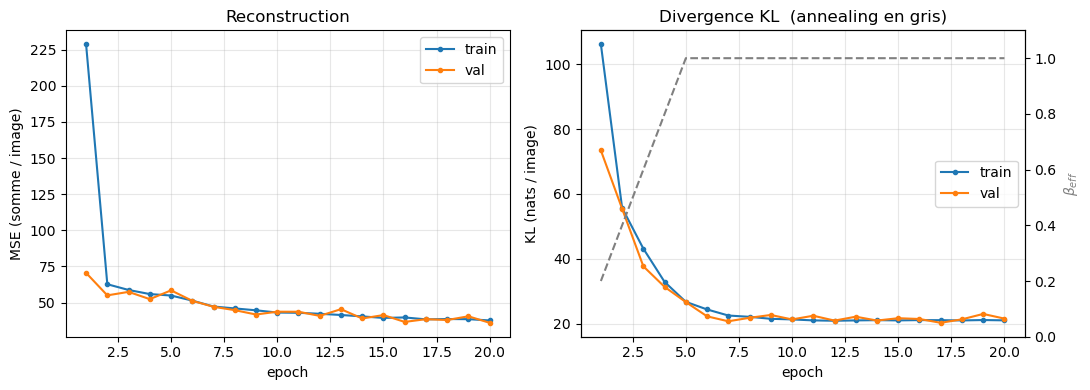

KL finale ≈ 21.6 nats/image — strictement > 0 : pas de posterior collapse.


In [10]:
# Courbes : reconstruction et KL (par image), + planning de beta_eff
ep = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ep, hist_vae["rec"],  "-o", ms=3, label="train")
axes[0].plot(ep, hist_vae["vrec"], "-o", ms=3, label="val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE (somme / image)")
axes[0].set_title("Reconstruction"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(ep, hist_vae["kl"],  "-o", ms=3, label="train")
axes[1].plot(ep, hist_vae["vkl"], "-o", ms=3, label="val")
ax2 = axes[1].twinx()
ax2.plot(ep, hist_vae["beta"], "--", color="gray", label=r"$\beta_{eff}$")
ax2.set_ylabel(r"$\beta_{eff}$", color="gray"); ax2.set_ylim(0, 1.1)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("KL (nats / image)")
axes[1].set_title("Divergence KL  (annealing en gris)")
axes[1].legend(loc="center right"); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"KL finale ≈ {hist_vae['vkl'][-1]:.1f} nats/image — strictement > 0 : pas de posterior collapse.")

## Partie VI — Reconstructions & génération

**Reconstruction** : pour l'affichage on décode $\boldsymbol{\mu}$ (le *mode* du postérieur) plutôt qu'un tirage — image plus stable.

**Génération** : on échantillonne $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ et on appelle `vae.decode(z)` — **sans encodeur**. Pour mesurer le chemin parcouru, on rejoue la même expérience sur le **décodeur de l'AE déterministe du TP 07** (checkpoint `convae_dermamnist_best.pt`).

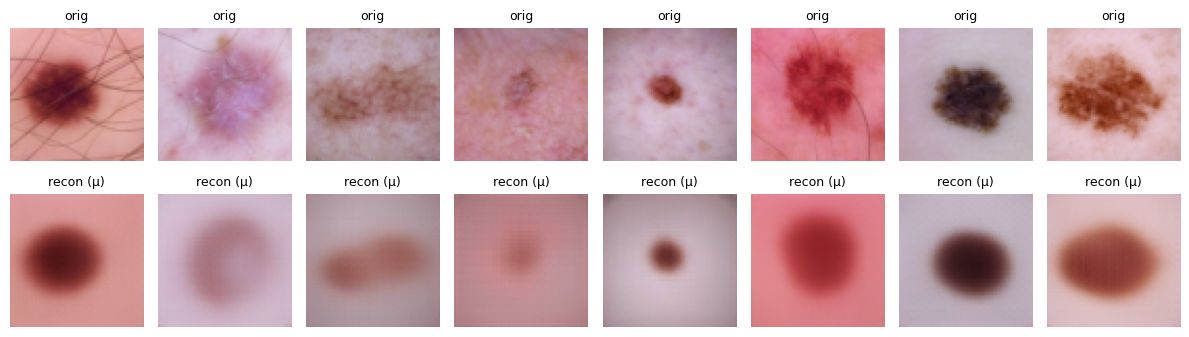

Reconstructions fidèles mais légèrement lissées — la moyenne gaussienne gomme les hautes fréquences.


In [11]:
# Originaux (haut) vs reconstructions via mu (bas) sur le test
@torch.no_grad()
def reconstruct_mu(model, x):
    model.eval()
    mu, _ = model.encode(x.to(device))
    return model.decode(mu).cpu()

x_test, y_test = next(iter(test_loader))
x_show = x_test[:8]
rec = reconstruct_mu(vae, x_show)
show_grid([*x_show, *rec], nrow=8,
          titles=["orig"]*8 + ["recon (μ)"]*8, figsize=(12, 3.6))
print("Reconstructions fidèles mais légèrement lissées — la moyenne gaussienne gomme les hautes fréquences.")

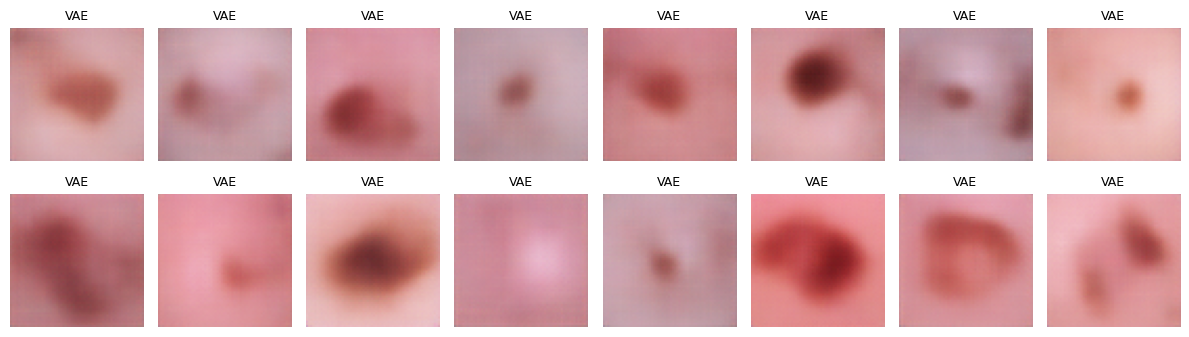

Lésions plausibles (teinte, halo, centre pigmenté) — floues, mais ÉCHANTILLONNÉES de zéro.


In [12]:
# Génération pure : z ~ N(0, I) -> decode
torch.manual_seed(SEED)
with torch.no_grad():
    z = torch.randn(16, vae.latent_dim, device=device)
    gen = vae.decode(z).cpu()
show_grid(list(gen), nrow=8, titles=["VAE"]*16, figsize=(12, 3.6))
print("Lésions plausibles (teinte, halo, centre pigmenté) — floues, mais ÉCHANTILLONNÉES de zéro.")

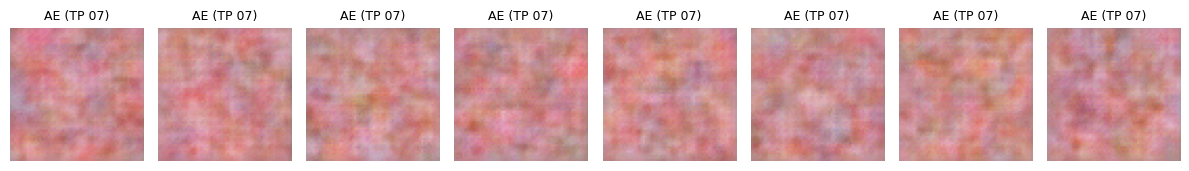

AE déterministe + z ~ N(0,I) : textures incohérentes — son latent n'est pas distribué selon le prior.
C'est le terme KL du VAE qui aligne le latent sur N(0, I) et rend l'échantillonnage possible.


In [13]:
# Contre-épreuve : même expérience sur l'AE déterministe du TP 07
class ConvAE(nn.Module):
    '''Copie de l'architecture du TP 07 — uniquement pour recharger le checkpoint.'''
    def __init__(self, base=32):
        super().__init__()
        self.encoder = nn.Sequential(
            enc_block(3,      base), enc_block(base, base * 2), enc_block(base*2, base * 4))
        self.decoder = nn.Sequential(
            dec_block(base*4, base * 2), dec_block(base*2, base), dec_block(base, 3, last=True))
    def forward(self, x):
        return self.decoder(self.encoder(x))

ae_path = CKPT_DIR / "convae_dermamnist_best.pt"
if ae_path.exists():
    conv_ae = ConvAE().to(device)
    conv_ae.load_state_dict(torch.load(ae_path, map_location=device)["state_dict"])
    conv_ae.eval()
    torch.manual_seed(SEED)
    with torch.no_grad():
        z_sp  = torch.randn(8, 128, 8, 8, device=device)   # latent spatial de l'AE ~ N(0, I)
        gen_ae = conv_ae.decoder(z_sp).cpu()
    show_grid(list(gen_ae), nrow=8, titles=["AE (TP 07)"]*8, figsize=(12, 1.9))
    print("AE déterministe + z ~ N(0,I) : textures incohérentes — son latent n'est pas distribué selon le prior.")
    print("C'est le terme KL du VAE qui aligne le latent sur N(0, I) et rend l'échantillonnage possible.")
else:
    print(f"Checkpoint {ae_path} introuvable — exécutez le TP 07 pour cette comparaison (sautée).")

## Partie VII — Interpolation latente : lerp vs slerp

On encode deux images de test ($\mathbf{z}=\boldsymbol{\mu}$), puis on décode 10 points du chemin — linéaire (**lerp**) et sphérique (**slerp**). Grâce au latent **continu et sans trous** du VAE, chaque image intermédiaire est plausible : c'est un **morphing sémantique**, impossible avec l'AE du TP 07.

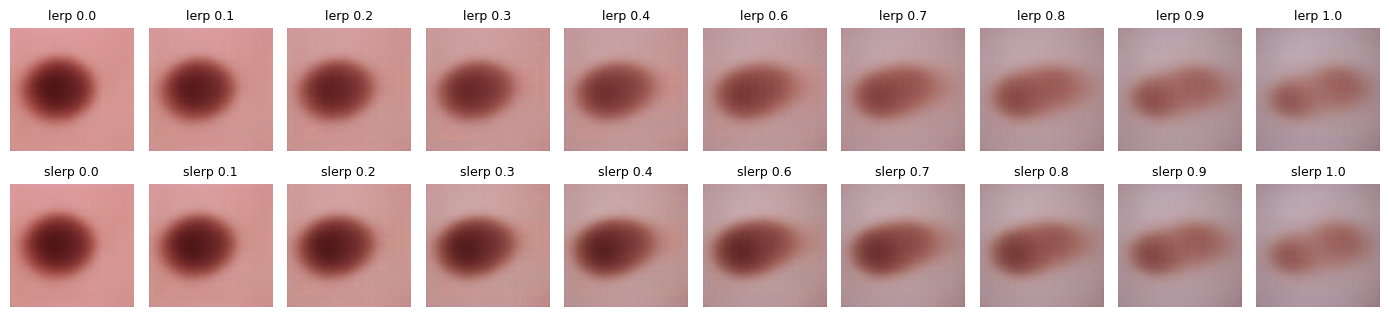

‖z‖ le long du lerp  : 3.8 -> 2.5 (milieu) -> 3.3   (norme typique du prior : √d = 11.3)
Le lerp « creuse » la norme au milieu du chemin ; le slerp la préserve (cf. exercice 7).


In [14]:
def slerp(z_a, z_b, t):
    '''Interpolation sphérique entre deux vecteurs latents (t scalaire dans [0,1]).'''
    a = z_a / z_a.norm(); b = z_b / z_b.norm()
    omega = torch.acos((a * b).sum().clamp(-1 + 1e-7, 1 - 1e-7))
    return (torch.sin((1 - t) * omega) * z_a + torch.sin(t * omega) * z_b) / torch.sin(omega)

# Deux images de classes différentes (nv -> mel si disponibles dans le batch)
idx_a = int(np.where(np.asarray(y_test) == CLASSES_SHORT.index("nv"))[0][0])
idx_b = int(np.where(np.asarray(y_test) == CLASSES_SHORT.index("mel"))[0][0])

vae.eval()
with torch.no_grad():
    mu_pair, _ = vae.encode(torch.stack([x_test[idx_a], x_test[idx_b]]).to(device))
    z_a, z_b = mu_pair[0], mu_pair[1]
    ts = torch.linspace(0, 1, 10)
    path_lerp  = torch.stack([torch.lerp(z_a, z_b, float(t)) for t in ts])
    path_slerp = torch.stack([slerp(z_a, z_b, float(t)) for t in ts])
    imgs_lerp  = vae.decode(path_lerp).cpu()
    imgs_slerp = vae.decode(path_slerp).cpu()

show_grid([*imgs_lerp, *imgs_slerp], nrow=10,
          titles=[f"lerp {t:.1f}" for t in ts] + [f"slerp {t:.1f}" for t in ts],
          figsize=(14, 3.4))
norms_l = [float(z.norm()) for z in path_lerp]
print(f"‖z‖ le long du lerp  : {norms_l[0]:.1f} -> {min(norms_l):.1f} (milieu) -> {norms_l[-1]:.1f}"
      f"   (norme typique du prior : √d = {np.sqrt(vae.latent_dim):.1f})")
print("Le lerp « creuse » la norme au milieu du chemin ; le slerp la préserve (cf. exercice 7).")

## Partie VIII — $\beta$-VAE & dimensions latentes actives

On réentraîne le même ConvVAE avec $\beta=0.1$ (KL presque débranchée) et $\beta=4$ ($\beta$-VAE), puis on compare au modèle $\beta=1$ :

- **reconstruction vs KL** : $\beta$ régule directement le compromis fidélité / régularité du latent ;
- **dimensions actives** : la KL totale se décompose par dimension, $\mathrm{KL} = \sum_j \mathrm{KL}_j$ avec $\mathrm{KL}_j = -\tfrac12(1+\log\sigma_j^2-\mu_j^2-\sigma_j^2)$ moyennée sur le dataset. Une dimension avec $\mathrm{KL}_j\approx 0$ est **morte** (collée au prior, aucune information). Plus $\beta$ augmente, moins il reste de dimensions actives — chacune devant « payer son loyer », le modèle concentre l'information sur quelques **facteurs de variation** (désenchevêtrement).

In [15]:
BETAS = [0.1, 4.0]
EPOCHS_BETA = 10
models_beta = {1.0: vae}
hists_beta  = {1.0: hist_vae}
for beta in BETAS:
    torch.manual_seed(SEED)
    m = ConvVAE().to(device)
    hists_beta[beta] = fit_vae(m, EPOCHS_BETA, lr=1e-3, beta=beta, warmup=3,
                               tag=f"VAE β={beta}")
    models_beta[beta] = m

[VAE β=0.1] epoch  1/10  β_eff 0.03  train rec  217.4  kl 6180.8  |  val rec   70.5  kl 218.7  (15.4s)
[VAE β=0.1] epoch  2/10  β_eff 0.07  train rec   49.5  kl 183.8  |  val rec   41.4  kl 152.3  (15.5s)
[VAE β=0.1] epoch  3/10  β_eff 0.10  train rec   43.1  kl 137.8  |  val rec   37.8  kl 134.6  (15.5s)
[VAE β=0.1] epoch  4/10  β_eff 0.10  train rec   37.1  kl 127.8  |  val rec   34.7  kl 119.5  (15.6s)
[VAE β=0.1] epoch  5/10  β_eff 0.10  train rec   33.4  kl 120.9  |  val rec   32.2  kl 115.9  (15.7s)
[VAE β=0.1] epoch  6/10  β_eff 0.10  train rec   31.1  kl 117.3  |  val rec   29.5  kl 108.3  (16.2s)
[VAE β=0.1] epoch  7/10  β_eff 0.10  train rec   29.1  kl 111.5  |  val rec   27.5  kl 109.1  (15.4s)
[VAE β=0.1] epoch  8/10  β_eff 0.10  train rec   27.6  kl 107.5  |  val rec   27.1  kl 108.2  (15.5s)
[VAE β=0.1] epoch  9/10  β_eff 0.10  train rec   27.3  kl 107.3  |  val rec   26.3  kl  99.8  (15.4s)
[VAE β=0.1] epoch 10/10  β_eff 0.10  train rec   25.8  kl 103.0  |  val rec   25.

    β |  val rec |  val KL | dims actives (KL_j > 0.02)
-------------------------------------------------------
  0.1 |     25.7 |    96.0 | 128 / 128
  1.0 |     36.0 |    21.6 |  35 / 128
  4.0 |     66.5 |     9.3 |  16 / 128


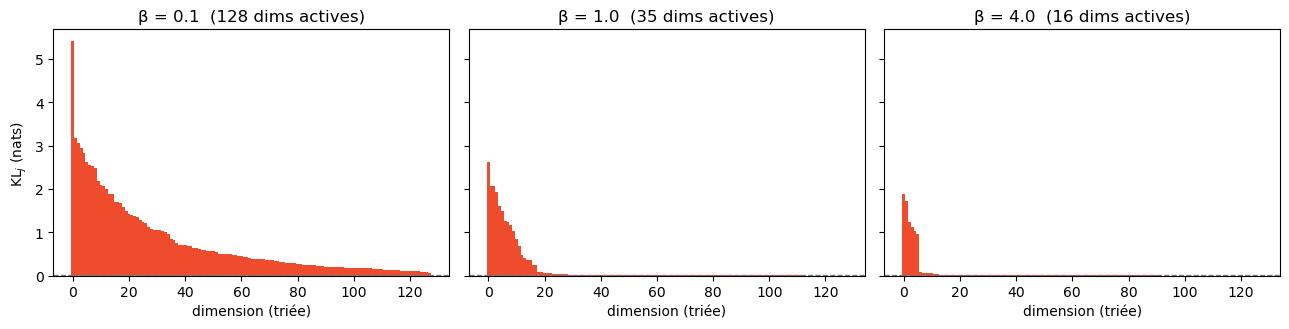

In [16]:
@torch.no_grad()
def kl_per_dim(model, loader, max_n=2000):
    '''KL moyenne par dimension latente sur ~max_n images (nats).'''
    model.eval(); acc, n = [], 0
    for x, _ in loader:
        mu, lv = model.encode(x.to(device))
        acc.append((-0.5 * (1 + lv - mu.pow(2) - lv.exp())).cpu())
        n += len(x)
        if n >= max_n:
            break
    return torch.cat(acc)[:max_n].mean(0).numpy()

ACTIVE_THR = 0.02   # nats : seuil en dessous duquel une dimension est « morte »
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharey=True)
print(f"{'β':>5} | {'val rec':>8} | {'val KL':>7} | dims actives (KL_j > {ACTIVE_THR})")
print("-" * 55)
for ax, beta in zip(axes, sorted(models_beta)):
    klj = np.sort(kl_per_dim(models_beta[beta], val_loader))[::-1]
    n_active = int((klj > ACTIVE_THR).sum())
    h = hists_beta[beta]
    print(f"{beta:>5} | {h['vrec'][-1]:8.1f} | {h['vkl'][-1]:7.1f} | {n_active:3d} / {LATENT_DIM}")
    ax.bar(range(LATENT_DIM), klj, width=1.0, color="#EE4C2C")
    ax.axhline(ACTIVE_THR, color="gray", ls="--", lw=1)
    ax.set_title(f"β = {beta}  ({n_active} dims actives)")
    ax.set_xlabel("dimension (triée)")
axes[0].set_ylabel("KL$_j$ (nats)")
plt.tight_layout(); plt.show()

——— β = 0.1 : reconstructions (haut) / échantillons du prior (bas) ———


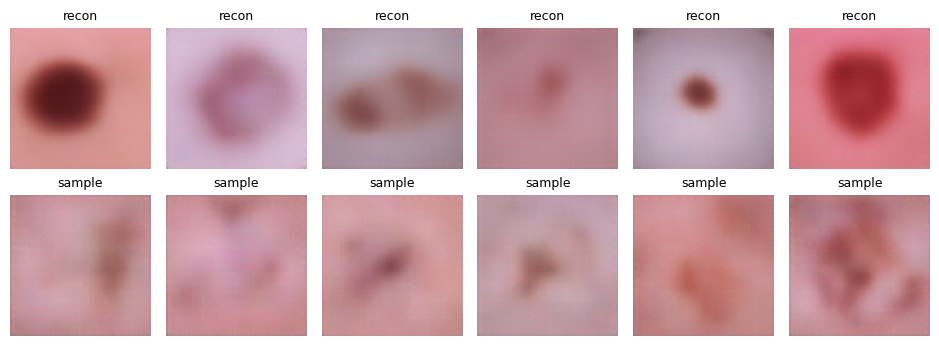

——— β = 1.0 : reconstructions (haut) / échantillons du prior (bas) ———


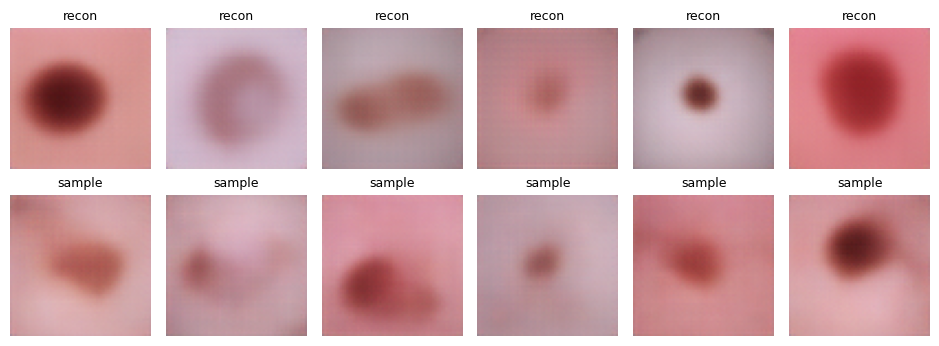

——— β = 4.0 : reconstructions (haut) / échantillons du prior (bas) ———


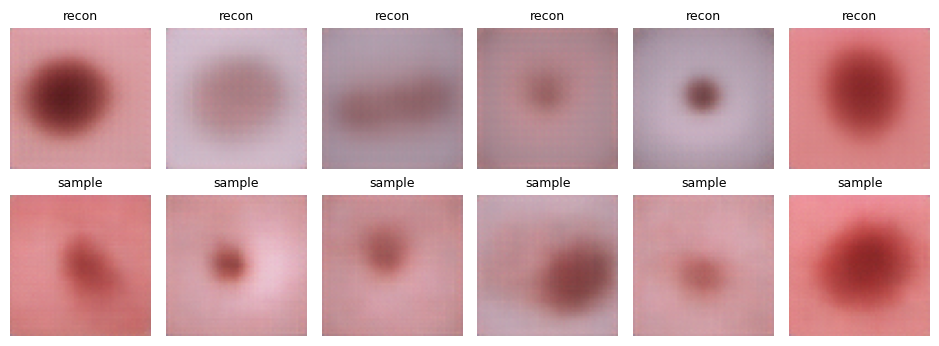

β petit : reconstructions nettes mais échantillons dégradés (latent mal aligné sur le prior).
β grand : tout est plus lisse/flou, mais le prior est mieux couvert et le latent plus parcimonieux.


In [17]:
# Effet visuel de beta : reconstructions (memes 6 images) et echantillons z ~ N(0,I)
x6 = x_test[:6]
torch.manual_seed(SEED)
z6 = torch.randn(6, LATENT_DIM, device=device)
for beta in sorted(models_beta):
    m = models_beta[beta]
    with torch.no_grad():
        rec6 = reconstruct_mu(m, x6)
        gen6 = m.decode(z6).cpu()
    print(f"——— β = {beta} : reconstructions (haut) / échantillons du prior (bas) ———")
    show_grid([*rec6, *gen6], nrow=6,
              titles=["recon"]*6 + ["sample"]*6, figsize=(9.5, 3.6))
print("β petit : reconstructions nettes mais échantillons dégradés (latent mal aligné sur le prior).")
print("β grand : tout est plus lisse/flou, mais le prior est mieux couvert et le latent plus parcimonieux.")

## Partie IX — Conditional VAE (CVAE)

Pour générer **une classe choisie**, on conditionne les deux réseaux par le label $\mathbf{y}$ (Partie I.5) via un `nn.Embedding(7, 16)` :

- **encodeur** : l'embedding est concaténé à la feature convolutive aplatie, avant les têtes $\boldsymbol{\mu}$ / $\log\boldsymbol{\sigma}^2$ → $q_\phi(\mathbf{z}|\mathbf{x},\mathbf{y})$ ;
- **décodeur** : l'embedding est concaténé à $\mathbf{z}$ avant la projection linéaire → $p_\theta(\mathbf{x}|\mathbf{z},\mathbf{y})$.

À l'inférence : $\hat{\mathbf{x}} = D_\theta(\mathbf{z}, \mathbf{y})$ avec $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ et $\mathbf{y}$ **au choix** — dont les classes rares de DermaMNIST (`df`, `vasc`), cas d'usage direct en **augmentation de données** médicales.

In [18]:
class CondConvVAE(nn.Module):
    '''ConvVAE conditionné par le label : embedding concaténé côté encodeur ET décodeur.'''
    def __init__(self, base=32, latent_dim=LATENT_DIM, img_size=IMG_SIZE,
                 n_classes=NUM_CLASSES, emb_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.feat_c  = base * 4
        self.feat_sp = img_size // 8
        feat_dim     = self.feat_c * self.feat_sp ** 2
        self.emb = nn.Embedding(n_classes, emb_dim)
        self.encoder = nn.Sequential(
            enc_block(3, base), enc_block(base, base * 2), enc_block(base*2, base * 4))
        self.fc_mu  = nn.Linear(feat_dim + emb_dim, latent_dim)
        self.fc_lv  = nn.Linear(feat_dim + emb_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim + emb_dim, feat_dim)
        self.decoder = nn.Sequential(
            dec_block(base*4, base * 2), dec_block(base*2, base), dec_block(base, 3, last=True))

    def encode(self, x, y):
        h = torch.cat([self.encoder(x).flatten(1), self.emb(y)], dim=1)
        return self.fc_mu(h), self.fc_lv(h)

    def reparameterize(self, mu, log_var):
        return mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)

    def decode(self, z, y):
        h = self.fc_dec(torch.cat([z, self.emb(y)], dim=1))
        return self.decoder(h.view(-1, self.feat_c, self.feat_sp, self.feat_sp))

    def forward(self, x, y):
        mu, log_var = self.encode(x, y)
        z = self.reparameterize(mu, log_var)
        return self.decode(z, y), mu, log_var

def fit_cvae(model, epochs, lr=1e-3, beta=1.0, warmup=5, tag="CVAE"):
    '''Même boucle que fit_vae, mais le label y est passé au modèle.'''
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"rec": [], "kl": [], "vrec": [], "vkl": []}
    for ep in range(1, epochs + 1):
        t0 = time.time()
        beta_eff = beta * min(1.0, ep / warmup)
        model.train(); tr_rec, tr_kl, n = 0.0, 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            x_hat, mu, log_var = model(x, y)
            loss, rec, kl = vae_loss(x_hat, x, mu, log_var, beta_eff)
            loss.backward(); optimizer.step()
            tr_rec += rec.item() * len(x); tr_kl += kl.item() * len(x); n += len(x)
        model.eval(); va_rec, va_kl, m_ = 0.0, 0.0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                x_hat, mu, log_var = model(x, y)
                _, rec, kl = vae_loss(x_hat, x, mu, log_var)
                va_rec += rec.item() * len(x); va_kl += kl.item() * len(x); m_ += len(x)
        for k, v in zip(("rec", "kl", "vrec", "vkl"),
                        (tr_rec/n, tr_kl/n, va_rec/m_, va_kl/m_)):
            hist[k].append(v)
        print(f"[{tag}] epoch {ep:2d}/{epochs}  β_eff {beta_eff:.2f}  "
              f"train rec {tr_rec/n:6.1f}  kl {tr_kl/n:5.1f}  |  "
              f"val rec {va_rec/m_:6.1f}  kl {va_kl/m_:5.1f}  ({time.time()-t0:.1f}s)")
    return hist

torch.manual_seed(SEED)
cvae = CondConvVAE().to(device)
print(f"CondConvVAE — paramètres : {count_params(cvae):,}")
hist_cvae = fit_cvae(cvae, 15, lr=1e-3, beta=1.0, warmup=5)

CondConvVAE — paramètres : 3,620,851
[CVAE] epoch  1/15  β_eff 0.20  train rec  210.5  kl  99.3  |  val rec   69.7  kl  65.9  (13.8s)
[CVAE] epoch  2/15  β_eff 0.40  train rec   62.5  kl  51.3  |  val rec   52.3  kl  48.3  (15.0s)
[CVAE] epoch  3/15  β_eff 0.60  train rec   55.5  kl  38.2  |  val rec   57.6  kl  37.7  (15.4s)
[CVAE] epoch  4/15  β_eff 0.80  train rec   53.5  kl  30.1  |  val rec   54.8  kl  25.6  (15.3s)
[CVAE] epoch  5/15  β_eff 1.00  train rec   52.0  kl  24.8  |  val rec   54.0  kl  21.8  (15.1s)
[CVAE] epoch  6/15  β_eff 1.00  train rec   49.3  kl  22.6  |  val rec   49.1  kl  19.5  (15.1s)
[CVAE] epoch  7/15  β_eff 1.00  train rec   45.3  kl  21.4  |  val rec   43.6  kl  21.6  (15.1s)
[CVAE] epoch  8/15  β_eff 1.00  train rec   45.5  kl  21.0  |  val rec   47.3  kl  19.3  (15.0s)
[CVAE] epoch  9/15  β_eff 1.00  train rec   43.8  kl  20.4  |  val rec   42.6  kl  19.8  (15.0s)
[CVAE] epoch 10/15  β_eff 1.00  train rec   42.8  kl  20.3  |  val rec   51.4  kl  17.2  (

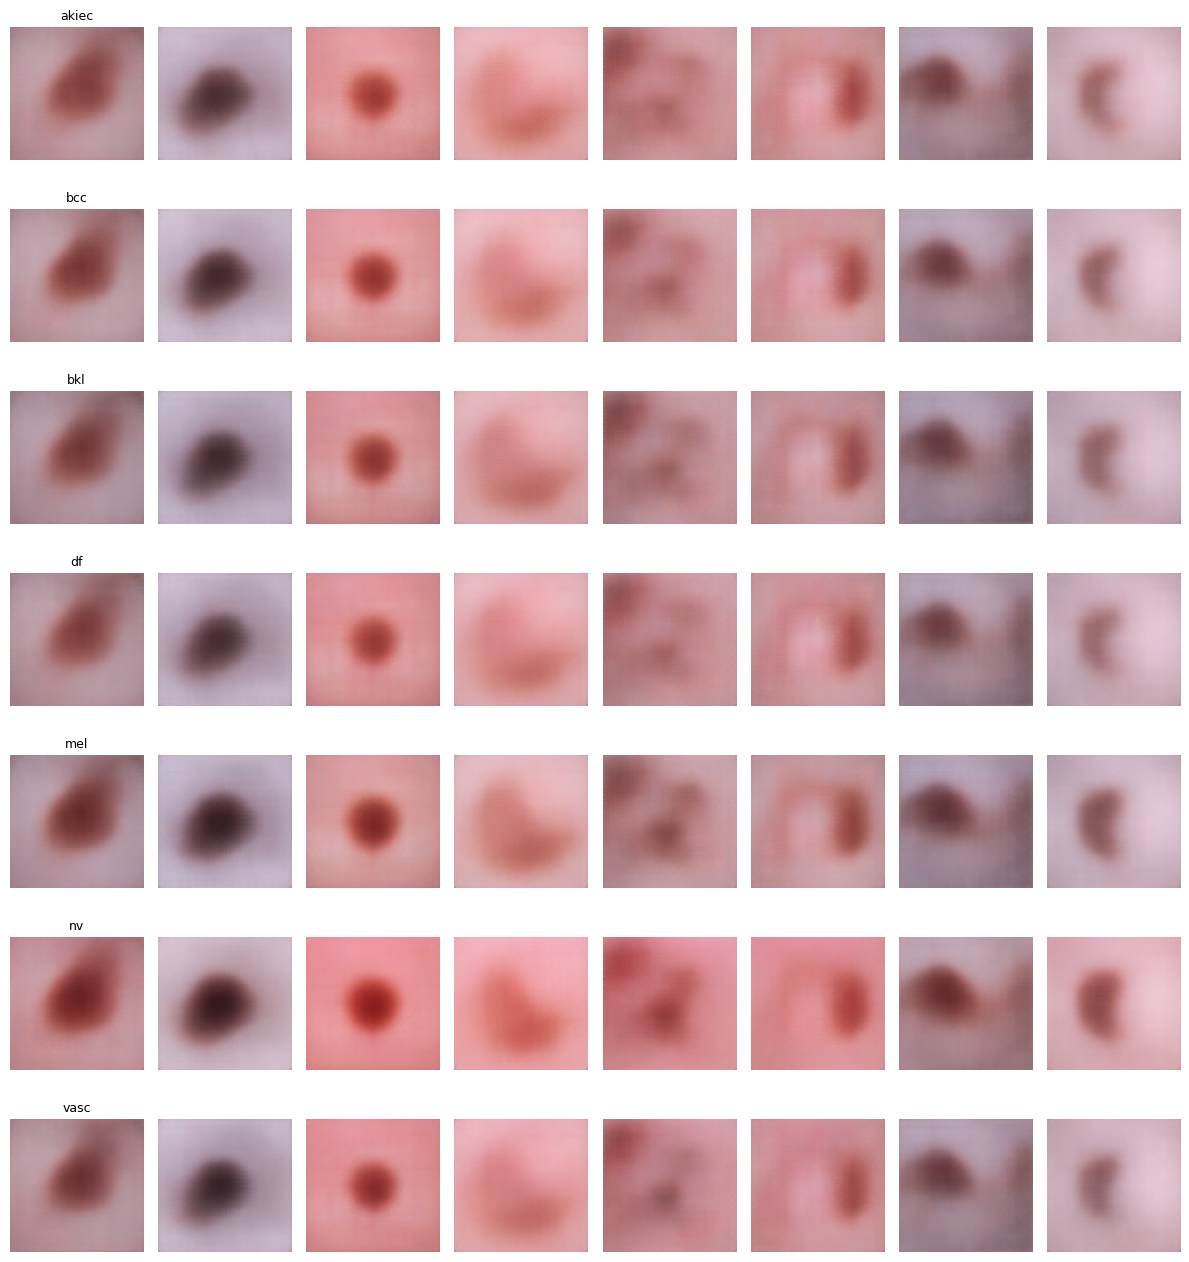

Même z par colonne, classe par ligne : le label pilote teinte/texture, z le « style ».
Les lignes df / vasc fournissent des échantillons synthétiques pour les classes rares (exercice 6).


In [19]:
# Génération CONTRÔLÉE : 8 échantillons par classe (z partagé entre les lignes)
torch.manual_seed(SEED)
z8 = torch.randn(8, LATENT_DIM, device=device)
rows = []
cvae.eval()
with torch.no_grad():
    for k in range(NUM_CLASSES):
        y = torch.full((8,), k, dtype=torch.long, device=device)
        rows.append(cvae.decode(z8, y).cpu())
imgs   = [img for row in rows for img in row]
titles = [CLASSES_SHORT[k] if j == 0 else "" for k in range(NUM_CLASSES) for j in range(8)]
show_grid(imgs, nrow=8, titles=titles, figsize=(12, 13))
print("Même z par colonne, classe par ligne : le label pilote teinte/texture, z le « style ».")
print("Les lignes df / vasc fournissent des échantillons synthétiques pour les classes rares (exercice 6).")

## Partie X — Espace latent : projection des $\boldsymbol{\mu}$

Comme au TP 07, on projette le latent en 2D (UMAP, repli PCA) — mais ici on projette les **moyennes $\boldsymbol{\mu}$** du postérieur. Différence attendue : le terme KL **tire tous les nuages vers l'origine** — le latent VAE est plus **compact et isotrope** (proche d'une gaussienne globale) que celui de l'AE, condition de la génération mais au prix de clusters moins étalés.

Latents extraits : (2000, 128)
‖μ‖ moyenne : 4.2   (norme typique du prior : √d = 11.3)


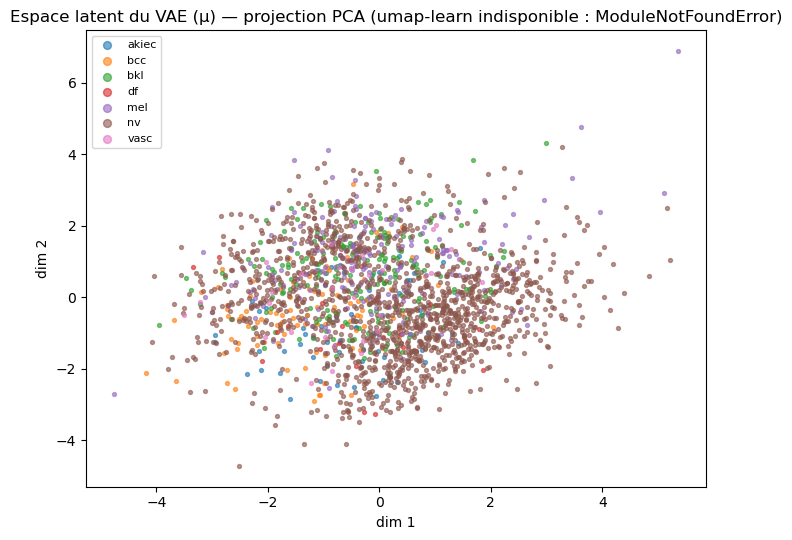

In [20]:
@torch.no_grad()
def extract_mus(model, loader, max_n=2000):
    model.eval()
    Z, Y = [], []
    for x, y in loader:
        mu, _ = model.encode(x.to(device))
        Z.append(mu.cpu().numpy()); Y.append(np.asarray(y))
        if sum(len(a) for a in Z) >= max_n:
            break
    return np.concatenate(Z)[:max_n], np.concatenate(Y)[:max_n]

Z, Y = extract_mus(vae, test_loader, max_n=2000)
print(f"Latents extraits : {Z.shape}")
print(f"‖μ‖ moyenne : {np.linalg.norm(Z, axis=1).mean():.1f}   (norme typique du prior : √d = {np.sqrt(LATENT_DIM):.1f})")

try:
    import umap
    emb = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    random_state=SEED).fit_transform(Z)
    method = "UMAP"
except Exception as e:
    from sklearn.decomposition import PCA
    emb = PCA(n_components=2, random_state=SEED).fit_transform(Z)
    method = f"PCA (umap-learn indisponible : {type(e).__name__})"

plt.figure(figsize=(7, 5.5))
for k in range(NUM_CLASSES):
    m = Y == k
    plt.scatter(emb[m, 0], emb[m, 1], s=8, alpha=.6, label=CLASSES_SHORT[k])
plt.title(f"Espace latent du VAE (μ) — projection {method}")
plt.xlabel("dim 1"); plt.ylabel("dim 2")
plt.legend(markerscale=2, fontsize=8, loc="best")
plt.tight_layout(); plt.show()

## Partie XI — VAE 1D : séries temporelles capteurs synthétiques

Le VAE n'est pas réservé aux images. Cas d'usage du plan de formation : **générer des trajectoires capteurs réalistes** pour l'**augmentation de données** (maintenance prédictive — les pannes sont rares, donc chères à collecter).

On simule des **signaux de vibration** (fondamentale $f\in[2,6]$ Hz d'amplitude variable + harmonique 2 + bruit), puis on entraîne un VAE **1D** : mêmes équations, seuls les modules changent (`nn.Conv1d` / `nn.ConvTranspose1d`). Deux différences avec les images :

- les signaux ne sont **pas bornés** dans $[0,1]$ → **pas de sigmoïde** en sortie (décodeur gaussien sur $\mathbb{R}$, MSE inchangée) ;
- le latent peut être **très petit** ($d=8$) : un signal est entièrement décrit par quelques facteurs (fréquence, amplitude, phase…).

In [21]:
SIG_LEN = 128

def make_signals(n, L=SIG_LEN, seed=0):
    '''Signaux de vibration simulés : fondamentale + harmonique 2 + bruit. Shape (n, 1, L).'''
    g = np.random.default_rng(seed)
    t   = np.linspace(0, 1, L, dtype=np.float32)
    f   = g.uniform(2.0, 6.0,       size=(n, 1)).astype(np.float32)   # fréquence fondamentale
    A   = g.uniform(0.5, 1.5,       size=(n, 1)).astype(np.float32)   # amplitude
    phi = g.uniform(0, 2 * np.pi,   size=(n, 1)).astype(np.float32)   # phase
    h2  = g.uniform(0.2, 0.5,       size=(n, 1)).astype(np.float32)   # poids harmonique 2
    x = A * np.sin(2*np.pi*f*t + phi) + h2 * A * np.sin(4*np.pi*f*t + 2*phi)
    x += g.normal(0, 0.05, size=x.shape).astype(np.float32)
    return torch.from_numpy(x).unsqueeze(1)

sig_train = make_signals(2048, seed=SEED)
sig_val   = make_signals(256,  seed=SEED + 1)
sig_train_loader = DataLoader(TensorDataset(sig_train, torch.zeros(len(sig_train))),
                              batch_size=128, shuffle=True)
sig_val_loader   = DataLoader(TensorDataset(sig_val, torch.zeros(len(sig_val))),
                              batch_size=128, shuffle=False)
print(f"Signaux : train {tuple(sig_train.shape)}  val {tuple(sig_val.shape)}")

class VAE1D(nn.Module):
    def __init__(self, latent_dim=8, L=SIG_LEN):
        super().__init__()
        self.latent_dim = latent_dim
        self.feat_l = L // 8                       # 3 strides de 2 : 128 -> 16
        feat_dim = 64 * self.feat_l
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 5, stride=2, padding=2),  nn.ReLU(inplace=True),
            nn.Conv1d(16, 32, 5, stride=2, padding=2), nn.ReLU(inplace=True),
            nn.Conv1d(32, 64, 5, stride=2, padding=2), nn.ReLU(inplace=True),
        )
        self.fc_mu  = nn.Linear(feat_dim, latent_dim)
        self.fc_lv  = nn.Linear(feat_dim, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, feat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1), nn.ReLU(inplace=True),
            nn.ConvTranspose1d(16, 1, 4, stride=2, padding=1),  # PAS de sigmoïde : signal non borné
        )

    def encode(self, x):
        h = self.encoder(x).flatten(1)
        return self.fc_mu(h), self.fc_lv(h)

    def decode(self, z):
        return self.decoder(self.fc_dec(z).view(-1, 64, self.feat_l))

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)
        return self.decode(z), mu, log_var

torch.manual_seed(SEED)
vae1d = VAE1D().to(device)
print(f"VAE1D — paramètres : {count_params(vae1d):,}  (latent d={vae1d.latent_dim})")

Signaux : train (2048, 1, 128)  val (256, 1, 128)
VAE1D — paramètres : 48,961  (latent d=8)


[VAE1D] epoch  1/40  train rec  80.23  kl  0.73
[VAE1D] epoch 10/40  train rec  10.79  kl 11.49
[VAE1D] epoch 20/40  train rec   8.37  kl 11.53
[VAE1D] epoch 30/40  train rec   6.80  kl 11.35
[VAE1D] epoch 40/40  train rec   6.12  kl 11.15


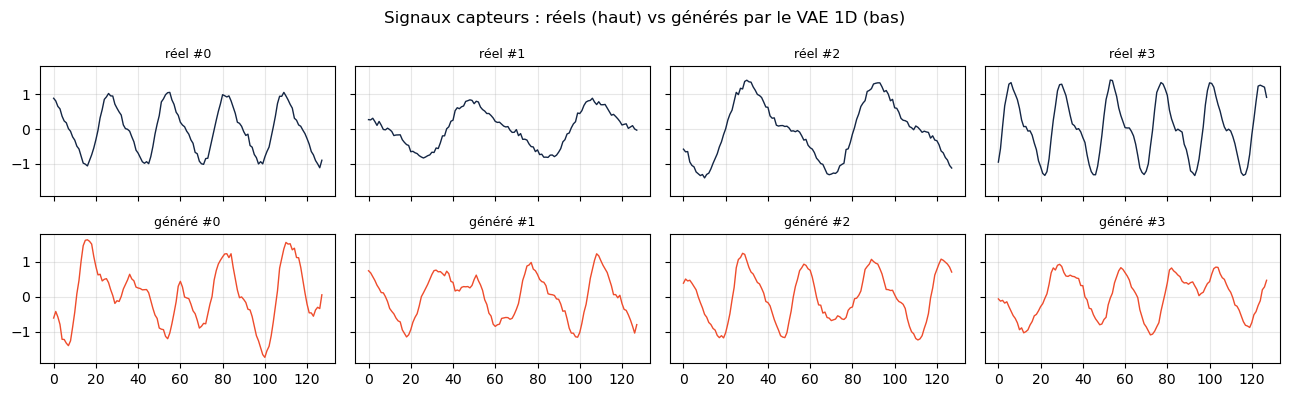

Les signaux générés respectent la structure fondamentale + harmonique — utilisables en augmentation.


In [22]:
# Entraînement (rapide) — mêmes fonctions, seuls les loaders changent
optimizer = torch.optim.Adam(vae1d.parameters(), lr=1e-3)
EPOCHS_1D = 40
for ep in range(1, EPOCHS_1D + 1):
    beta_eff = min(1.0, ep / 5)
    vae1d.train(); tr_rec, tr_kl, n = 0.0, 0.0, 0
    for x, _ in sig_train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_hat, mu, log_var = vae1d(x)
        loss, rec, kl = vae_loss(x_hat, x, mu, log_var, beta_eff)
        loss.backward(); optimizer.step()
        tr_rec += rec.item() * len(x); tr_kl += kl.item() * len(x); n += len(x)
    if ep % 10 == 0 or ep == 1:
        print(f"[VAE1D] epoch {ep:2d}/{EPOCHS_1D}  train rec {tr_rec/n:6.2f}  kl {tr_kl/n:5.2f}")

# Réels (haut) vs générés z ~ N(0,I) (bas)
torch.manual_seed(SEED)
vae1d.eval()
with torch.no_grad():
    gen_sig = vae1d.decode(torch.randn(4, vae1d.latent_dim, device=device)).cpu()
fig, axes = plt.subplots(2, 4, figsize=(13, 4), sharex=True, sharey=True)
for j in range(4):
    axes[0, j].plot(sig_val[j, 0], lw=1, color="#142644")
    axes[0, j].set_title(f"réel #{j}", fontsize=9)
    axes[1, j].plot(gen_sig[j, 0], lw=1, color="#EE4C2C")
    axes[1, j].set_title(f"généré #{j}", fontsize=9)
for ax in axes.ravel():
    ax.grid(alpha=.3)
plt.suptitle("Signaux capteurs : réels (haut) vs générés par le VAE 1D (bas)")
plt.tight_layout(); plt.show()
print("Les signaux générés respectent la structure fondamentale + harmonique — utilisables en augmentation.")

## Partie XII — Sauvegarde des modèles

Convention du dépôt : `<arch>_<dataset>_best.pt` dans `./checkpoints/`. Le CVAE sera réutilisable pour l'augmentation (exercice 6) ; le VAE $\beta=1$ sert de référence pour le TP 09.

In [23]:
def save_ckpt(model, name, extra=None):
    path = CKPT_DIR / name
    payload = {"state_dict": model.state_dict(), "img_size": IMG_SIZE, "arch": type(model).__name__}
    if extra:
        payload.update(extra)
    torch.save(payload, path)
    print(f"✓ {path}  ({path.stat().st_size/1e6:.1f} Mo)")

save_ckpt(vae, "vae_dermamnist_best.pt",
          extra={"latent_dim": LATENT_DIM, "beta": 1.0,
                 "val_rec": hist_vae["vrec"][-1], "val_kl": hist_vae["vkl"][-1]})
save_ckpt(models_beta[4.0], "betavae4_dermamnist_best.pt",
          extra={"latent_dim": LATENT_DIM, "beta": 4.0})
save_ckpt(cvae, "cvae_dermamnist_best.pt",
          extra={"latent_dim": LATENT_DIM, "beta": 1.0, "emb_dim": 16,
                 "val_rec": hist_cvae["vrec"][-1], "val_kl": hist_cvae["vkl"][-1]})
save_ckpt(vae1d, "vae1d_series_best.pt",
          extra={"latent_dim": vae1d.latent_dim, "sig_len": SIG_LEN})

✓ checkpoints/vae_dermamnist_best.pt  (14.0 Mo)
✓ checkpoints/betavae4_dermamnist_best.pt  (14.0 Mo)
✓ checkpoints/cvae_dermamnist_best.pt  (14.5 Mo)
✓ checkpoints/vae1d_series_best.pt  (0.2 Mo)


## Partie XIII — Exercices d'application

### Exercice 1 — Dimension latente
Réentraînez le `ConvVAE` avec $d \in \{16, 64, 256\}$. Tracez `val rec` et `val KL` en fonction de $d$, et comparez la qualité des **échantillons** $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$. Un grand $d$ améliore-t-il forcément la génération ? Reliez au nombre de **dimensions actives** (Partie VIII).

### Exercice 2 — Décodeur Bernoulli (BCE)
Remplacez la MSE par `F.binary_cross_entropy(x_hat, x, reduction="sum")` (décodeur Bernoulli). Comparez la netteté des reconstructions **et** l'équilibre reconstruction/KL : pourquoi le changement d'échelle de la loss de reconstruction modifie-t-il le $\beta$ effectif ?

### Exercice 3 — Posterior collapse
Supprimez le KL annealing (`warmup=1`) et entraînez avec $\beta=8$. Tracez la KL par epoch et générez des échantillons : observez-vous l'effondrement ($\mathrm{KL}\to 0$, sorties quasi identiques) ? Rétablissez l'annealing avec `warmup=10` et comparez.

### Exercice 4 — Traversée latente ($\beta$-VAE)
Sur le modèle $\beta=4$, repérez les 3 dimensions les plus actives (Partie VIII). Pour une image de test, faites varier $z_j \in [-3, 3]$ (les autres dimensions fixées) et décodez. Les facteurs de variation sont-ils interprétables (teinte globale, taille de la lésion, contraste…) ?

### Exercice 5 — Détection OOD par ELBO
Calculez $-\mathcal{L}_{\text{ELBO}}$ par image (rec + KL, sans moyenne batch) sur le test. En prenant `nv` comme classe « normale », tracez la distribution des scores `nv` vs autres classes et la courbe ROC (`sklearn.metrics.roc_auc_score`). Comparez à l'AUC du TP 07 (score = erreur de reconstruction seule) : le terme KL améliore-t-il la calibration ?

### Exercice 6 — Augmentation CVAE des classes rares
Générez 500 images de `df` et 500 de `vasc` avec le CVAE et ajoutez-les au train du CNN du TP 03 (`smallvgg`). Le **macro-F1** s'améliore-t-il sur ces classes ? Discutez les limites : images floues, distribution biaisée vers le mode, risque de renforcer les biais du générateur.

### Exercice 7 — Géométrie du prior : lerp vs slerp
Tracez $\|\mathbf{z}_t\|$ pour $t\in[0,1]$ le long du lerp et du slerp entre deux codes (Partie VII), et comparez à $\sqrt{d}$. Échantillonnez 1000 points $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I}_d)$ et tracez l'histogramme de $\|\mathbf{z}\|$ : pourquoi dit-on que la masse du prior se concentre sur une « coquille » de rayon $\sqrt{d}$, et qu'est-ce que cela implique pour le milieu du chemin lerp ?

---

## Synthèse — API PyTorch du VAE

| Concept | API PyTorch |
|---------|-------------|
| Têtes $\boldsymbol{\mu}$ et $\log\boldsymbol{\sigma}^2$ | deux `nn.Linear` sur la feature partagée de l'encodeur |
| Reparametrization trick | `z = mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)` |
| Idem via `torch.distributions` | `Normal(mu, std).rsample()` (`.sample()` coupe le gradient) |
| KL en forme close | `-0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())` |
| KL de vérification | `kl_divergence(Normal(mu, std), Normal(0., 1.))` |
| Loss VAE ($-$ELBO) | `F.mse_loss(x_hat, x, reduction="sum") + beta * kl` |
| $\beta$-VAE / KL annealing | `beta_eff = beta * min(1, epoch / warmup)` |
| Génération | `model.decode(torch.randn(n, latent_dim))` — décodeur seul |
| Dimensions actives | $\mathrm{KL}_j$ moyenne par dimension $>$ seuil (≈ 0.02 nats) |
| Conditional VAE | `nn.Embedding(n_classes, e)` concaténé à la feature **et** à $\mathbf{z}$ |
| Interpolation latente | `torch.lerp(z_a, z_b, t)` / slerp manuel (`acos` + `sin`) |
| VAE 1D (séries) | `nn.Conv1d` / `nn.ConvTranspose1d`, sortie **sans** sigmoïde |

---

**Prochain TP** (Module 3) : *Modèles de diffusion — DDPM & DDIM* — processus avant/inverse, U-Net conditionné par le timestep, sampling accéléré ; le flou du VAE y trouve sa réponse.